# 03 — Thailand Province GIS
## Area, Attribute Query, Statistics & Choropleth Mapping

**กลุ่มผู้เรียน:** ปริญญาตรีปี 3–4 และปริญญาโทปี 1–2 สาขาวิทยาศาสตร์สิ่งแวดล้อม  
**ระดับ:** Beginner → Intermediate  
**ข้อมูล:** Thailand ADM1 Provinces  
**เครื่องมือ:** GeoPandas · Pandas · Matplotlib · Folium · MapClassify

Notebook นี้ต่อจาก Notebook 02 โดยเปลี่ยนคำถามจาก

> **“เราวัดพื้นที่ได้ถูกต้องหรือยัง?”**

ไปเป็น

> **“เมื่อวัดได้ถูกต้องแล้ว เราจะค้นหารูปแบบ เปรียบเทียบ ทำสถิติ และสื่อสารด้วยแผนที่อย่างไร?”**

แนวคิดหลัก:

$$
\text{Inspect}
\rightarrow
\text{Measure}
\rightarrow
\text{Query}
\rightarrow
\text{Summarize}
\rightarrow
\text{Classify}
\rightarrow
\text{Map}
\rightarrow
\text{Interpret}
\rightarrow
\text{Export}
$$

## Learning objectives

เมื่อเรียนจบ Notebook นี้ นิสิตควรสามารถ

1. ตรวจ schema, geometry, CRS และ unique identifier ของข้อมูลจังหวัด
2. อธิบายได้ว่าเหตุใดจึงไม่ควรเชื่อ field เช่น `Shape_Area` โดยไม่รู้หน่วยและ CRS
3. คำนวณพื้นที่จังหวัดทั้งประเทศด้วย **equal-area projection**
4. ใช้ descriptive statistics กับข้อมูลเชิงพื้นที่
5. ทำ attribute query ด้วยชื่อและค่าตัวเลข
6. หา Top 10 จังหวัดพื้นที่มากที่สุดและน้อยที่สุด
7. อธิบายความแตกต่างระหว่าง reference map, categorical map และ choropleth map
8. เปรียบเทียบ Equal Interval กับ Quantiles
9. สร้างและ join attribute ของภูมิภาค
10. สรุปสถิติรายภูมิภาคด้วย `groupby()`
11. แสดงผลแบบ interactive ด้วย Folium
12. สร้าง publication-quality maps และ export ไปใช้ต่อใน QGIS

## 1. Recap จาก Notebook 02

Notebook 02 สอนว่า

$$
\boxed{
\text{CRS}
\rightarrow
\text{Units}
\rightarrow
\text{Measurement}
}
$$

และหลักสำคัญคือ

$$
\boxed{
\text{Choose CRS based on the spatial question}
}
$$

สำหรับบทนี้ เราต้องการ **เปรียบเทียบพื้นที่จังหวัดทั้งประเทศ**  
จึงเลือก projection ที่รักษาพื้นที่ แทนที่จะใช้ Web Mercator หรือ UTM zone เดียวทั้งประเทศ

## 2. คำถามเปิดบท

ประเทศไทยมี 77 จังหวัด แต่

- จังหวัดใดมีพื้นที่มากที่สุด?
- พื้นที่จังหวัดมี distribution แบบใด?
- จังหวัดขนาดใหญ่กระจายอยู่บริเวณใด?
- ถ้าแบ่งข้อมูลด้วย Equal Interval กับ Quantiles แผนที่จะเปลี่ยนหรือไม่?
- ภูมิภาคใดมีพื้นที่รวมมากที่สุด?
- จำนวนจังหวัดมากที่สุด แปลว่าพื้นที่รวมมากที่สุดหรือไม่?

นี่คือการเปลี่ยนจาก **GIS display** ไปสู่ **GIS analysis + cartographic communication**

## 3. ติดตั้ง libraries

In [1]:
%pip -q install geopandas folium mapclassify xyzservices pyogrio

In [2]:
from pathlib import Path
import shutil
import zipfile

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium
import xyzservices.providers as xyz
import mapclassify

from IPython.display import display

print("GeoPandas  :", gpd.__version__)
print("Pandas     :", pd.__version__)
print("Folium     :", folium.__version__)
print("MapClassify:", mapclassify.__version__)

GeoPandas  : 1.2.0
Pandas     : 2.2.3
Folium     : 0.20.0
MapClassify: 2.10.0


## 4. Font ภาษาไทย

ใช้ **Sarabun** จาก Google Fonts โดยดาวน์โหลด `.ttf` โดยตรง  
เพื่อให้ labels, title, legend และกราฟภาษาไทยแสดงผลสม่ำเสมอใน Colab

In [3]:
FONT_URL = (
    "https://raw.githubusercontent.com/"
    "google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf"
)

FONT_FILE = Path("/content/Sarabun-Regular.ttf")

if not FONT_FILE.exists():
    response = requests.get(FONT_URL, timeout=60)
    response.raise_for_status()
    FONT_FILE.write_bytes(response.content)

mpl.font_manager.fontManager.addfont(str(FONT_FILE))

font_name = mpl.font_manager.FontProperties(
    fname=str(FONT_FILE)
).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

print("Thai font ready:", font_name)

Thai font ready: Sarabun


## 5. Workspace

In [4]:
DATA_DIR = Path("/content/gis03_data")
OUTPUT_DIR = Path("/content/gis03_outputs")

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data folder   :", DATA_DIR)
print("Output folder :", OUTPUT_DIR)

Data folder   : /content/gis03_data
Output folder : /content/gis03_outputs


## 6. Download helper

In [5]:
def download_and_extract_zip(url, zip_name, extract_name):
    zip_path = DATA_DIR / zip_name
    extract_dir = DATA_DIR / extract_name

    if not zip_path.exists():
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        zip_path.write_bytes(response.content)

    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    shp_files = list(extract_dir.rglob("*.shp"))

    if not shp_files:
        raise FileNotFoundError(
            f"ไม่พบ .shp ภายใน {zip_name}"
        )

    print("ZIP      :", zip_path)
    print("Extracted:", extract_dir)
    print("Shapefile:", shp_files[0])

    return shp_files[0]

# Part A — Load & Inspect Thailand ADM1

## 7. Download Thailand Province Shapefile

In [6]:
ADM1_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/tha_adm1/tha_adm1_province_shapefile.zip"
)

adm1_shp = download_and_extract_zip(
    ADM1_URL,
    "tha_adm1_province_shapefile.zip",
    "tha_adm1"
)

ZIP      : /content/gis03_data/tha_adm1_province_shapefile.zip
Extracted: /content/gis03_data/tha_adm1
Shapefile: /content/gis03_data/tha_adm1/tha_adm1_province.shp


## 8. อ่าน Shapefile ด้วย UTF-8

ถ้าชื่อไทยแสดงเป็น `à¸...` นั่นคือ **encoding problem** ไม่ใช่ font problem

ดังนั้นเราจะอ่านด้วย

```python
encoding="UTF-8"
```

In [7]:
province = gpd.read_file(
    adm1_shp,
    encoding="UTF-8"
)

print("Features:", len(province))
print("CRS:", province.crs)
print("Columns:")
print(list(province.columns))

display(province.head())

Features: 77
CRS: EPSG:4326
Columns:
['Shape_Leng', 'Shape_Area', 'ADM1_EN', 'ADM1_TH', 'ADM1_PCODE', 'ADM1_REF', 'ADM1ALT1EN', 'ADM1ALT2EN', 'ADM1ALT1TH', 'ADM1ALT2TH', 'ADM0_EN', 'ADM0_TH', 'ADM0_PCODE', 'date', 'validOn', 'validTo', 'geometry']


,Shape_Leng,Shape_Area,ADM1_EN,ADM1_TH,ADM1_PCODE,ADM1_REF,ADM1ALT1EN,ADM1ALT2EN,ADM1ALT1TH,ADM1ALT2TH,ADM0_EN,ADM0_TH,ADM0_PCODE,date,validOn,validTo,geometry
0,2.417227,0.131339,Bangkok,กรุงเทพมหานคร,TH10,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.91398 13.94655, 100.90848 13.902..."
1,1.695100,0.079262,Samut Prakan,สมุทรปราการ,TH11,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.86078 13.6969, 100.8774 13.68972..."
2,1.251111,0.053238,Nonthaburi,นนทบุรี,TH12,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.56748 13.95118, 100.54364 13.849..."
3,1.884945,0.126983,Pathum Thani,ปทุมธานี,TH13,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.95121 14.27166, 100.9497 14.2666..."
4,3.041716,0.213938,Phra Nakhon Si Ayutthaya,พระนครศรีอยุธยา,TH14,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.60223 14.65499, 100.59705 14.650..."


## 9. ตรวจชื่อจังหวัดภาษาไทย

In [8]:
if {"ADM1_EN", "ADM1_TH"}.issubset(province.columns):
    display(
        province[
            ["ADM1_EN", "ADM1_TH", "ADM1_PCODE"]
        ].head(10)
    )
else:
    print("โปรดตรวจชื่อ field จาก schema จริง")

,ADM1_EN,ADM1_TH,ADM1_PCODE
0,Bangkok,กรุงเทพมหานคร,TH10
1,Samut Prakan,สมุทรปราการ,TH11
2,Nonthaburi,นนทบุรี,TH12
3,Pathum Thani,ปทุมธานี,TH13
4,Phra Nakhon Si Ayutthaya,พระนครศรีอยุธยา,TH14
5,Ang Thong,อ่างทอง,TH15
6,Lop Buri,ลพบุรี,TH16
7,Sing Buri,สิงห์บุรี,TH17
8,Chai Nat,ชัยนาท,TH18
9,Saraburi,สระบุรี,TH19


## 10. Geometry Quality Control

In [9]:
province_qc = pd.DataFrame({
    "Count": [
        len(province),
        province.geometry.isna().sum(),
        province.geometry.is_empty.sum(),
        (~province.is_valid.fillna(False)).sum()
    ]
}, index=[
    "All records",
    "Missing geometry",
    "Empty geometry",
    "Invalid / unavailable geometry"
])

display(province_qc)

print("\nGeometry types:")
display(province.geom_type.value_counts())

,Count
All records,77
Missing geometry,0
Empty geometry,0
Invalid / unavailable geometry,0



Geometry types:


,count
Polygon,64
MultiPolygon,13


## 11. Unique identifier

ชื่อจังหวัดเหมาะสำหรับอ่านโดยมนุษย์ แต่การ join ข้อมูลควรมี key ที่ชัดเจน

ในชุดนี้เราใช้

```text
ADM1_PCODE
```

แนวคิด:

```text
ADM1_TH     → Thai label
ADM1_EN     → English label
ADM1_PCODE  → identifier / join key
```

In [10]:
print(
    "Unique province codes:",
    province["ADM1_PCODE"].nunique()
)

print(
    "Duplicated codes:",
    province["ADM1_PCODE"].duplicated().sum()
)

display(
    province[
        ["ADM1_PCODE", "ADM1_EN", "ADM1_TH"]
    ].head()
)

Unique province codes: 77
Duplicated codes: 0


,ADM1_PCODE,ADM1_EN,ADM1_TH
0,TH10,Bangkok,กรุงเทพมหานคร
1,TH11,Samut Prakan,สมุทรปราการ
2,TH12,Nonthaburi,นนทบุรี
3,TH13,Pathum Thani,ปทุมธานี
4,TH14,Phra Nakhon Si Ayutthaya,พระนครศรีอยุธยา


## 12. First boundary map

ก่อนทำ thematic map ให้ดู geometry ก่อน

แผนที่นี้เป็น **reference / boundary map**

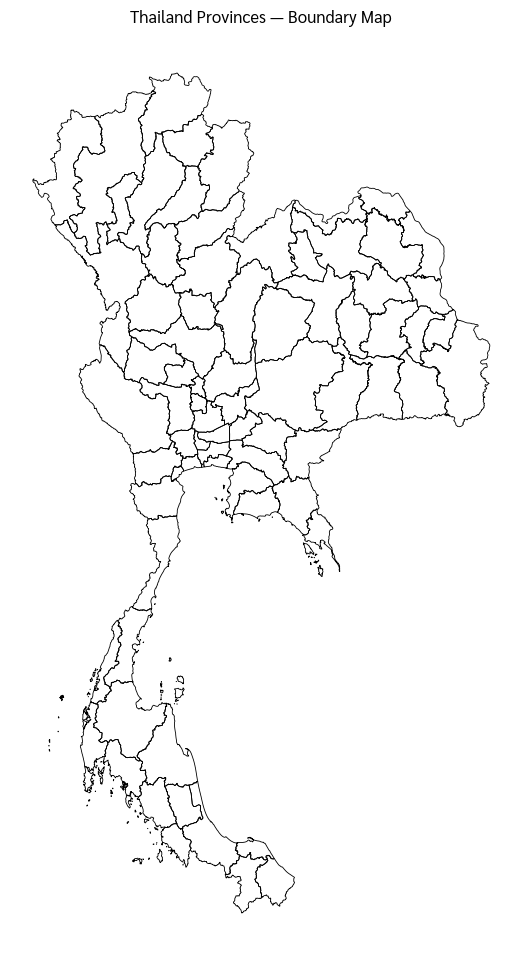

In [11]:
fig, ax = plt.subplots(figsize=(8, 12))

province.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Thailand Provinces — Boundary Map")
ax.set_axis_off()

plt.show()

# Part B — Area Measurement

## 13. ทำไมไม่ใช้ `Shape_Area` ทันที?

ใน attribute table มี field ชื่อคล้าย

```text
Shape_Area
```

แต่ชื่อ field ไม่ได้บอกว่า

- คำนวณใน CRS ใด
- หน่วยเป็นอะไร
- ถูกสร้างเมื่อใด
- ยังเหมาะกับ analysis ปัจจุบันหรือไม่

หลักที่ควรจำ:

> **Never trust a field name without knowing its units and CRS.**

In [12]:
display(
    province[
        ["ADM1_EN", "ADM1_TH", "Shape_Area"]
    ].head(10)
)

,ADM1_EN,ADM1_TH,Shape_Area
0,Bangkok,กรุงเทพมหานคร,0.131339
1,Samut Prakan,สมุทรปราการ,0.079262
2,Nonthaburi,นนทบุรี,0.053238
3,Pathum Thani,ปทุมธานี,0.126983
4,Phra Nakhon Si Ayutthaya,พระนครศรีอยุธยา,0.213938
5,Ang Thong,อ่างทอง,0.079210
6,Lop Buri,ลพบุรี,0.545788
7,Sing Buri,สิงห์บุรี,0.068727
8,Chai Nat,ชัยนาท,0.209078
9,Saraburi,สระบุรี,0.292087


## 14. ใช้ Equal-area projection

วัตถุประสงค์ของเราคือ **เปรียบเทียบพื้นที่จังหวัดทั่วประเทศ**

เราจึงใช้

```text
EPSG:6933
WGS 84 / NSIDC EASE-Grid 2.0 Global
```

แล้วคำนวณ

$$
A_{km^2}
=
\frac{
A_{m^2}
}{
10^6
}
$$

In [13]:
province_ea = province.to_crs("EPSG:6933")

print("Analysis CRS:", province_ea.crs)

province_ea["area_km2"] = (
    province_ea.geometry.area
    / 1_000_000
)

display(
    province_ea[
        ["ADM1_EN", "ADM1_TH", "area_km2"]
    ].head(10)
)

Analysis CRS: EPSG:6933


,ADM1_EN,ADM1_TH,area_km2
0,Bangkok,กรุงเทพมหานคร,1571.994060
1,Samut Prakan,สมุทรปราการ,948.567952
2,Nonthaburi,นนทบุรี,636.437786
3,Pathum Thani,ปทุมธานี,1517.754260
4,Phra Nakhon Si Ayutthaya,พระนครศรีอยุธยา,2552.174011
5,Ang Thong,อ่างทอง,944.002171
6,Lop Buri,ลพบุรี,6490.513242
7,Sing Buri,สิงห์บุรี,817.952429
8,Chai Nat,ชัยนาท,2487.098010
9,Saraburi,สระบุรี,3482.752063


## 15. ตรวจพื้นที่จังหวัดพิษณุโลก

Notebook 02 ใช้ UTM Zone 47N สำหรับพื้นที่ local  
Notebook 03 ใช้ Equal-area projection สำหรับเปรียบเทียบพื้นที่ทั้งประเทศ

ค่าควรอยู่ในลำดับเดียวกัน แม้อาจไม่เท่ากันทุกหลักทศนิยม

In [14]:
phs_check = province_ea[
    province_ea["ADM1_TH"]
    .astype(str)
    .str.contains("พิษณุโลก", na=False)
][["ADM1_EN", "ADM1_TH", "area_km2"]]

display(phs_check)

,ADM1_EN,ADM1_TH,area_km2
52,Phitsanulok,พิษณุโลก,10523.897506


# Part C — Descriptive Statistics

## 16. `describe()`

เมื่อเรามีตัวแปรเชิงปริมาณ เช่น `area_km2` เราสามารถสรุป distribution ด้วย descriptive statistics

In [15]:
area_desc = (
    province_ea["area_km2"]
    .describe()
    .to_frame("area_km2")
)

display(
    area_desc.round(2)
)

,area_km2
count,77.00
mean,6692.57
std,4743.52
min,414.68
25%,3482.75
50%,5584.77
75%,9512.69
max,22177.88


## 17. Mean, Median และ Standard Deviation

ค่าเฉลี่ย:

$$
\bar{x}
=
\frac{1}{n}
\sum_{i=1}^{n}x_i
$$

ส่วนเบี่ยงเบนมาตรฐานของตัวอย่าง:

$$
s=
\sqrt{
\frac{
\sum_{i=1}^{n}
(x_i-\bar{x})^2
}{
n-1
}
}
$$

Median คือค่ากึ่งกลางหลังเรียงข้อมูลจากน้อยไปมาก

In [16]:
mean_area = province_ea["area_km2"].mean()
median_area = province_ea["area_km2"].median()
std_area = province_ea["area_km2"].std()

summary_stats = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Standard deviation"
    ],
    "Area_km2": [
        mean_area,
        median_area,
        std_area
    ]
})

display(
    summary_stats.round(2)
)

,Statistic,Area_km2
0,Mean,6692.57
1,Median,5584.77
2,Standard deviation,4743.52


### Interpretation

ถ้า mean สูงกว่า median อย่างเห็นได้ชัด อาจสะท้อนว่า distribution มีจังหวัดขนาดใหญ่มากบางแห่งที่ดึงค่าเฉลี่ยขึ้น

เราจะตรวจด้วย histogram และ boxplot

## 18. Histogram

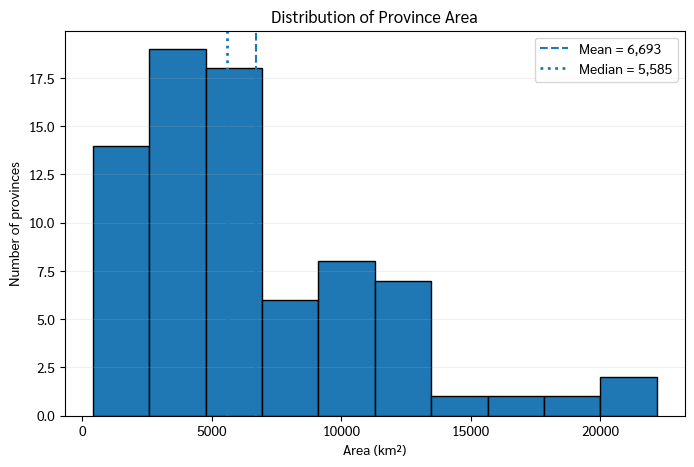

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    province_ea["area_km2"],
    bins=10,
    edgecolor="black"
)

ax.axvline(
    mean_area,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {mean_area:,.0f}"
)

ax.axvline(
    median_area,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_area:,.0f}"
)

ax.set_title("Distribution of Province Area")
ax.set_xlabel("Area (km²)")
ax.set_ylabel("Number of provinces")
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.show()

## 19. Boxplot

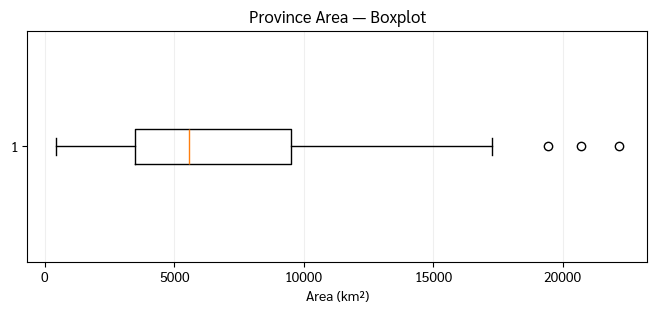

In [18]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.boxplot(
    province_ea["area_km2"],
    vert=False
)

ax.set_title("Province Area — Boxplot")
ax.set_xlabel("Area (km²)")
ax.grid(axis="x", alpha=0.2)

plt.show()

# Part D — Attribute Query

## 20. Query ด้วยชื่อจังหวัด

In [19]:
phitsanulok = province_ea[
    province_ea["ADM1_TH"]
    .astype(str)
    .str.contains("พิษณุโลก", na=False)
].copy()

display(
    phitsanulok[
        ["ADM1_EN", "ADM1_TH", "area_km2"]
    ]
)

,ADM1_EN,ADM1_TH,area_km2
52,Phitsanulok,พิษณุโลก,10523.897506


## 21. Query ด้วยค่าตัวเลข

เลือกจังหวัดที่มีพื้นที่มากกว่า 10,000 km²

In [20]:
large_provinces = province_ea[
    province_ea["area_km2"] > 10_000
].copy()

large_provinces = large_provinces.sort_values(
    "area_km2",
    ascending=False
)

print(
    "Number of provinces > 10,000 km²:",
    len(large_provinces)
)

display(
    large_provinces[
        ["ADM1_TH", "ADM1_EN", "area_km2"]
    ].round(1)
)

Number of provinces > 10,000 km²: 17


,ADM1_TH,ADM1_EN,area_km2
38,เชียงใหม่,Chiang Mai,22177.9
18,นครราชสีมา,Nakhon Ratchasima,20707.5
56,กาญจนบุรี,Kanchanaburi,19449.1
50,ตาก,Tak,17279.9
22,อุบลราชธานี,Ubon Ratchathani,15482.6
67,สุราษฎร์ธานี,Surat Thani,13076.2
46,แม่ฮ่องสอน,Mae Hong Son,12770.7
24,ชัยภูมิ,Chaiyaphum,12617.3
40,ลำปาง,Lampang,12496.8
54,เพชรบูรณ์,Phetchabun,12388.6


## 22. Query ช่วงค่า

เลือกจังหวัดที่มีพื้นที่ระหว่าง 5,000–10,000 km²

In [21]:
mid_area = province_ea[
    province_ea["area_km2"].between(
        5_000,
        10_000
    )
].copy()

print("Selected provinces:", len(mid_area))

display(
    mid_area[
        ["ADM1_TH", "area_km2"]
    ]
    .sort_values(
        "area_km2",
        ascending=False
    )
    .round(1)
)

Selected provinces: 26


,ADM1_TH,area_km2
63,นครศรีธรรมราช,9901.6
35,สกลนคร,9527.0
47,นครสวรรค์,9512.7
21,ศรีสะเกษ,8885.2
20,สุรินทร์,8817.0
49,กำแพงเพชร,8558.7
41,อุตรดิตถ์,7918.7
33,ร้อยเอ็ด,7818.7
70,สงขลา,7741.1
34,กาฬสินธุ์,6886.9


# Part E — Ranking

## 23. Top 10 จังหวัดพื้นที่มากที่สุด

In [22]:
top10 = (
    province_ea
    .nlargest(
        10,
        "area_km2"
    )
    .copy()
)

top10["rank"] = range(
    1,
    len(top10) + 1
)

display(
    top10[
        [
            "rank",
            "ADM1_TH",
            "ADM1_EN",
            "area_km2"
        ]
    ].round(1)
)

,rank,ADM1_TH,ADM1_EN,area_km2
38,1,เชียงใหม่,Chiang Mai,22177.9
18,2,นครราชสีมา,Nakhon Ratchasima,20707.5
56,3,กาญจนบุรี,Kanchanaburi,19449.1
50,4,ตาก,Tak,17279.9
22,5,อุบลราชธานี,Ubon Ratchathani,15482.6
67,6,สุราษฎร์ธานี,Surat Thani,13076.2
46,7,แม่ฮ่องสอน,Mae Hong Son,12770.7
24,8,ชัยภูมิ,Chaiyaphum,12617.3
40,9,ลำปาง,Lampang,12496.8
54,10,เพชรบูรณ์,Phetchabun,12388.6


## 24. Bar chart — Top 10

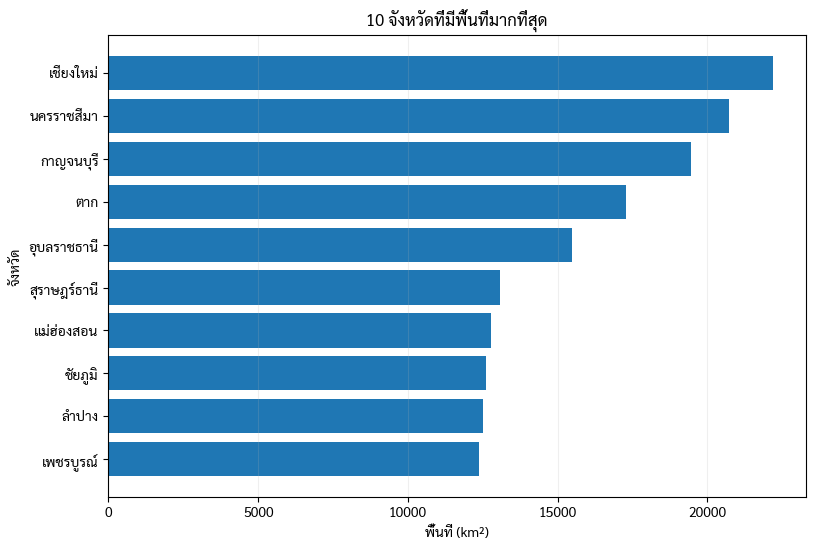

In [23]:
top10_bar = top10.sort_values(
    "area_km2",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top10_bar["ADM1_TH"],
    top10_bar["area_km2"]
)

ax.set_title("10 จังหวัดที่มีพื้นที่มากที่สุด")
ax.set_xlabel("พื้นที่ (km²)")
ax.set_ylabel("จังหวัด")
ax.grid(axis="x", alpha=0.2)

plt.show()

## 25. Highlight Top 10 บนแผนที่ประเทศไทย

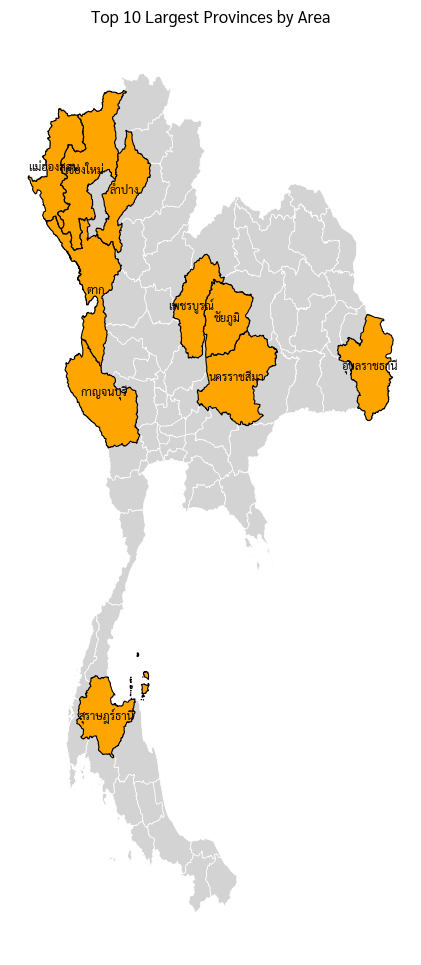

In [24]:
fig, ax = plt.subplots(figsize=(8, 12))

province_ea.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="white",
    linewidth=0.5
)

top10.plot(
    ax=ax,
    facecolor="orange",
    edgecolor="black",
    linewidth=0.8
)

label_pts = top10.geometry.representative_point()

for idx, pt in label_pts.items():
    ax.text(
        pt.x,
        pt.y,
        str(top10.loc[idx, "ADM1_TH"]),
        fontsize=8,
        ha="center",
        va="center"
    )

ax.set_title("Top 10 Largest Provinces by Area")
ax.set_axis_off()

plt.show()

### Try it

เปลี่ยนจาก

```python
.nlargest(10, "area_km2")
```

เป็น

```python
.nsmallest(10, "area_km2")
```

แล้วสร้างตาราง กราฟ และแผนที่ใหม่

# Part F — Choropleth Mapping

## 26. Choropleth คืออะไร?

Choropleth ใช้สีหรือความเข้มแทน **ค่าตัวเลขของ polygon**

$$
Color_i=f(z_i)
$$

ในบทนี้

$$
z_i=Area_i
$$

ดังนั้น province area เป็นตัวแปรเชิงปริมาณที่เหมาะสำหรับการสาธิต choropleth

## 27. Continuous color map

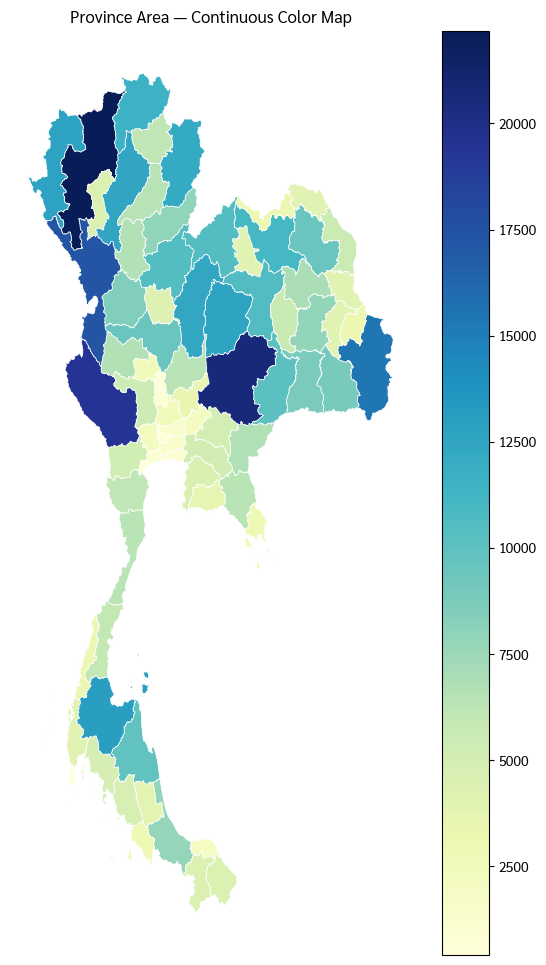

In [25]:
fig, ax = plt.subplots(figsize=(8, 12))

province_ea.plot(
    ax=ax,
    column="area_km2",
    cmap="YlGnBu",
    legend=True,
    edgecolor="white",
    linewidth=0.5
)

ax.set_title("Province Area — Continuous Color Map")
ax.set_axis_off()

plt.show()

## 28. Equal Interval

ถ้าแบ่งข้อมูลเป็น $k$ classes ที่มีช่วงค่ากว้างเท่ากัน

$$
w=
\frac{
x_{max}-x_{min}
}{
k
}
$$

เหมาะเมื่อเราต้องการให้ class ranges มีความกว้างเท่ากัน

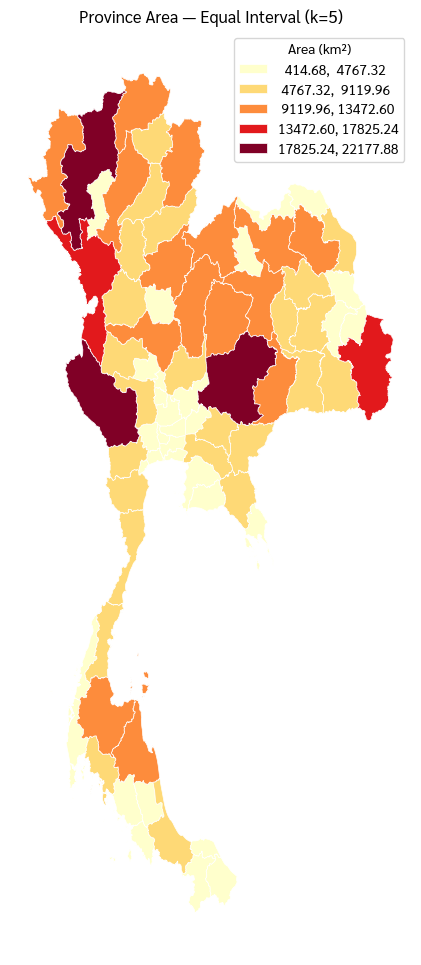

In [26]:
fig, ax = plt.subplots(figsize=(8, 12))

province_ea.plot(
    ax=ax,
    column="area_km2",
    scheme="EqualInterval",
    k=5,
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={
        "title": "Area (km²)"
    }
)

ax.set_title(
    "Province Area — Equal Interval (k=5)"
)
ax.set_axis_off()

plt.show()

## 29. Quantiles

Quantile classification พยายามให้แต่ละ class มีจำนวน features ใกล้เคียงกัน

ดังนั้น

```text
Equal Interval
→ ช่วงตัวเลขใกล้เคียงกัน

Quantiles
→ จำนวนจังหวัดต่อ class ใกล้เคียงกัน
```

ข้อมูลเดิม แต่ classification scheme ต่างกัน → แผนที่อาจเล่าเรื่องต่างกัน

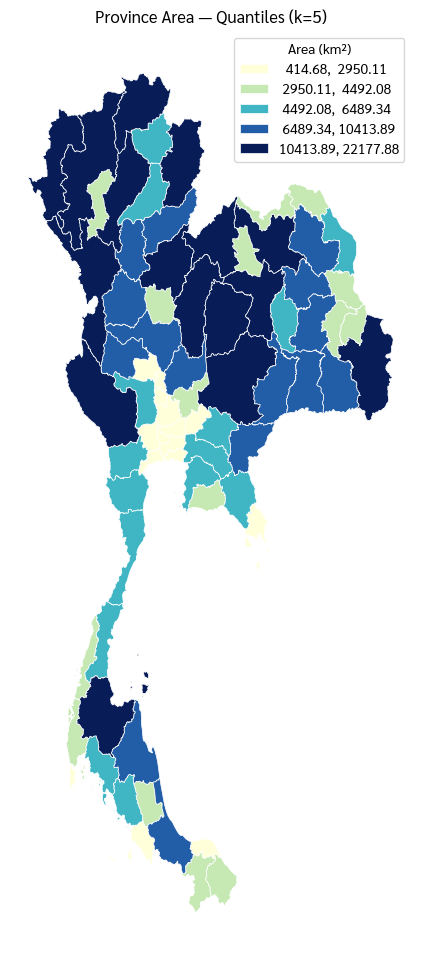

In [27]:
fig, ax = plt.subplots(figsize=(8, 12))

province_ea.plot(
    ax=ax,
    column="area_km2",
    scheme="Quantiles",
    k=5,
    cmap="YlGnBu",
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={
        "title": "Area (km²)"
    }
)

ax.set_title(
    "Province Area — Quantiles (k=5)"
)
ax.set_axis_off()

plt.show()

### Interpretation exercise

เปรียบเทียบ Equal Interval และ Quantiles แล้วตอบ:

1. จังหวัดใดเปลี่ยน class?
2. แผนที่ใดกระจายสีได้สมดุลกว่า?
3. แผนที่ใดสะท้อน “ช่วงค่าพื้นที่จริง” มากกว่า?
4. ถ้านำไปตีพิมพ์ เราควรระบุ classification scheme ใน caption หรือไม่?

> **คำตอบ:** ควรระบุ เพราะ classification เป็นส่วนหนึ่งของการตีความแผนที่

## 30. ข้อควรระวังของ Choropleth

ในบทนี้เราใช้ `area_km2` เพื่อเรียนรู้เทคนิคการทำ choropleth

แต่ในงานสิ่งแวดล้อมจริง ตัวแปรบางชนิดไม่ควร map ด้วย raw count โดยตรง เช่น

```text
Population
Disease cases
Hospitals
Villages
```

หลายกรณีควร normalize ด้วยพื้นที่หรือประชากร เช่น

$$
Density=
rac{
Count
}{
Area
}
$$

แนวคิดนี้จะกลับมาอีกครั้งใน Notebook หมู่บ้าน

# Part G — Thai Labels & Reference Map

## 31. Representative point สำหรับ label

`representative_point()` เหมาะกับการวาง label เพราะจุดอยู่ภายใน polygon

In [28]:
label_gdf = province_ea[
    ["ADM1_PCODE", "ADM1_TH", "geometry"]
].copy()

label_gdf["label_point"] = (
    label_gdf.geometry
    .representative_point()
)

display(
    label_gdf[
        ["ADM1_TH", "label_point"]
    ].head()
)

,ADM1_TH,label_point
0,กรุงเทพมหานคร,POINT (9706836.169 1734763.303)
1,สมุทรปราการ,POINT (9718133.916 1719019.464)
2,นนทบุรี,POINT (9685573.681 1764483.742)
3,ปทุมธานี,POINT (9709110.676 1779931.069)
4,พระนครศรีอยุธยา,POINT (9700237.588 1817171.393)


## 32. Reference map 77 จังหวัดพร้อมชื่อภาษาไทย

การใส่ label 77 จังหวัดอาจมี overlap ในพื้นที่ที่จังหวัดมีขนาดเล็ก  
นี่เป็น **cartographic problem** ไม่ใช่ Python error

เราจะใช้แผนที่นี้เพื่อเรียนเรื่อง label density และ hierarchy

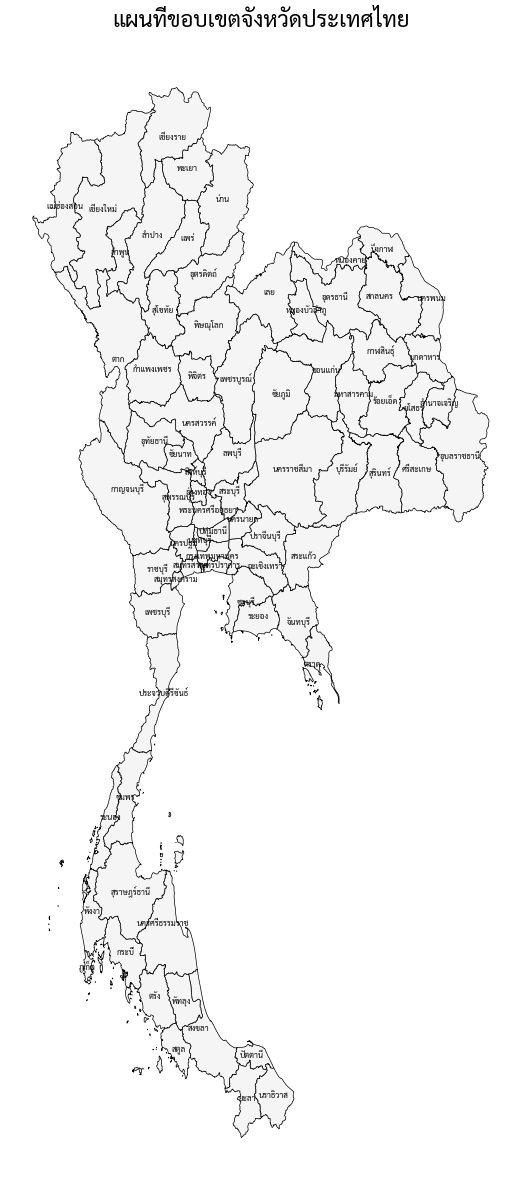

In [29]:
fig, ax = plt.subplots(figsize=(10, 15))

province_ea.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="black",
    linewidth=0.5
)

for idx, row in label_gdf.iterrows():
    pt = row["label_point"]

    ax.text(
        pt.x,
        pt.y,
        str(row["ADM1_TH"]),
        fontsize=5.8,
        ha="center",
        va="center"
    )

ax.set_title(
    "แผนที่ขอบเขตจังหวัดประเทศไทย",
    fontsize=16,
    fontweight="bold"
)

ax.set_axis_off()

plt.show()

# Part H — Derived Attribute: Region

## 33. ข้อมูลเดิมไม่มี field REGION

นี่เป็นโอกาสเรียนรู้ **derived attribute** และ **attribute join**

> ประเทศไทยมีหลายระบบแบ่งภูมิภาค  
> Notebook นี้ใช้ **ตัวอย่าง 6 ภูมิภาคเพื่อการเรียนการสอน**  
> งานวิจัยจริงควรระบุแหล่งอ้างอิงของระบบภูมิภาคที่เลือกใช้

กลุ่มตัวอย่าง:

```text
เหนือ
ตะวันออกเฉียงเหนือ
กลาง
ตะวันออก
ตะวันตก
ใต้
```

In [30]:
north = [
    "Chiang Mai", "Chiang Rai", "Lampang", "Lamphun",
    "Mae Hong Son", "Nan", "Phayao", "Phrae", "Uttaradit"
]

northeast = [
    "Amnat Charoen", "Bueng Kan", "Buri Ram", "Chaiyaphum",
    "Kalasin", "Khon Kaen", "Loei", "Maha Sarakham",
    "Mukdahan", "Nakhon Phanom", "Nakhon Ratchasima",
    "Nong Bua Lam Phu", "Nong Khai", "Roi Et",
    "Sakon Nakhon", "Si Sa Ket", "Surin",
    "Ubon Ratchathani", "Udon Thani", "Yasothon"
]

east = [
    "Chachoengsao", "Chanthaburi", "Chon Buri",
    "Prachin Buri", "Rayong", "Sa Kaeo", "Trat"
]

west = [
    "Kanchanaburi", "Tak", "Phetchaburi",
    "Prachuap Khiri Khan", "Ratchaburi"
]

south = [
    "Chumphon", "Krabi", "Nakhon Si Thammarat",
    "Narathiwat", "Pattani", "Phangnga", "Phatthalung",
    "Phuket", "Ranong", "Satun", "Songkhla",
    "Surat Thani", "Trang", "Yala"
]

# จังหวัดที่เหลือถูกกำหนดเป็นภาคกลาง
all_names = set(
    province_ea["ADM1_EN"]
    .astype(str)
    .str.strip()
)

used = (
    set(north)
    | set(northeast)
    | set(east)
    | set(west)
    | set(south)
)

central = sorted(
    all_names - used
)

region_rows = []

for name in north:
    region_rows.append(
        [name, "เหนือ", "North"]
    )

for name in northeast:
    region_rows.append(
        [name, "ตะวันออกเฉียงเหนือ", "Northeast"]
    )

for name in central:
    region_rows.append(
        [name, "กลาง", "Central"]
    )

for name in east:
    region_rows.append(
        [name, "ตะวันออก", "East"]
    )

for name in west:
    region_rows.append(
        [name, "ตะวันตก", "West"]
    )

for name in south:
    region_rows.append(
        [name, "ใต้", "South"]
    )

region_table = pd.DataFrame(
    region_rows,
    columns=[
        "ADM1_EN",
        "REGION_TH",
        "REGION_EN"
    ]
)

display(region_table.head(15))
print("Rows in region lookup:", len(region_table))

,ADM1_EN,REGION_TH,REGION_EN
0,Chiang Mai,เหนือ,North
1,Chiang Rai,เหนือ,North
2,Lampang,เหนือ,North
3,Lamphun,เหนือ,North
4,Mae Hong Son,เหนือ,North
5,Nan,เหนือ,North
6,Phayao,เหนือ,North
7,Phrae,เหนือ,North
8,Uttaradit,เหนือ,North
9,Amnat Charoen,ตะวันออกเฉียงเหนือ,Northeast


Rows in region lookup: 77


## 34. Attribute Join ด้วยชื่อจังหวัดอังกฤษ

นี่คือ **attribute join** เพราะเราเชื่อมข้อมูลด้วย key ที่มีค่าเหมือนกันในสองตาราง

```text
Province GeoDataFrame
       +
Region lookup table
       ↓
merge(on="ADM1_EN")
```

ต่างจาก spatial join ซึ่งจะเรียนในบทต่อ ๆ ไป

In [31]:
province_region = province_ea.merge(
    region_table,
    on="ADM1_EN",
    how="left"
)

print(
    "Unmatched region records:",
    province_region["REGION_TH"].isna().sum()
)

display(
    province_region[
        [
            "ADM1_EN",
            "ADM1_TH",
            "REGION_TH",
            "area_km2"
        ]
    ].head(15)
)

Unmatched region records: 0


,ADM1_EN,ADM1_TH,REGION_TH,area_km2
0,Bangkok,กรุงเทพมหานคร,กลาง,1571.994060
1,Samut Prakan,สมุทรปราการ,กลาง,948.567952
2,Nonthaburi,นนทบุรี,กลาง,636.437786
3,Pathum Thani,ปทุมธานี,กลาง,1517.754260
4,Phra Nakhon Si Ayutthaya,พระนครศรีอยุธยา,กลาง,2552.174011
5,Ang Thong,อ่างทอง,กลาง,944.002171
6,Lop Buri,ลพบุรี,กลาง,6490.513242
7,Sing Buri,สิงห์บุรี,กลาง,817.952429
8,Chai Nat,ชัยนาท,กลาง,2487.098010
9,Saraburi,สระบุรี,กลาง,3482.752063


In [32]:
if province_region["REGION_TH"].isna().any():
    print("Unmatched province names:")
    display(
        province_region.loc[
            province_region["REGION_TH"].isna(),
            ["ADM1_EN", "ADM1_TH"]
        ]
    )
else:
    print("Region join complete: all provinces matched.")

Region join complete: all provinces matched.


## 35. Region map เป็น Categorical Thematic Map

`REGION_TH` เป็น **category** ไม่ใช่ค่าตัวเลข

ดังนั้นแผนที่นี้ไม่ใช่ quantitative choropleth

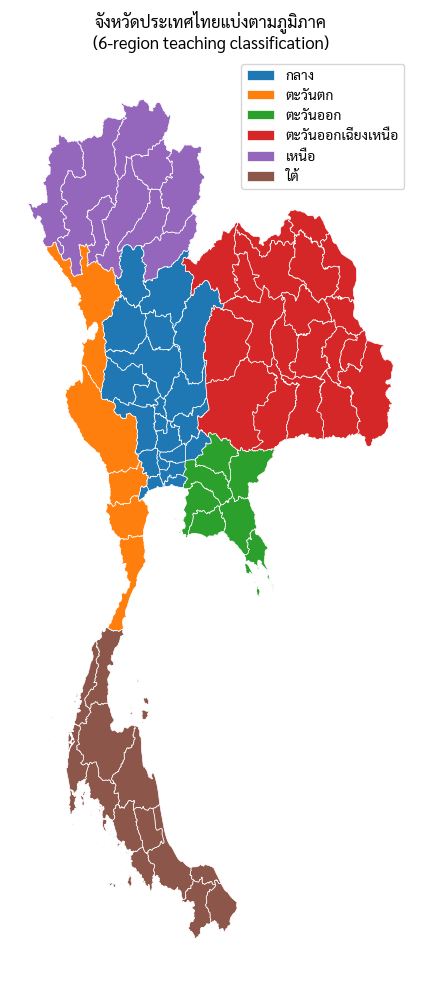

In [33]:
fig, ax = plt.subplots(figsize=(8, 12))

province_region.plot(
    ax=ax,
    column="REGION_TH",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.5
)

ax.set_title(
    "จังหวัดประเทศไทยแบ่งตามภูมิภาค\n"
    "(6-region teaching classification)"
)
ax.set_axis_off()

plt.show()

# Part I — Statistics by Region

## 36. `groupby()` และ aggregation

พื้นที่รวมของภูมิภาค $r$:

$$
A_r=
\sum_{i\in r}A_i
$$

พื้นที่จังหวัดเฉลี่ยในภูมิภาค:

$$
\bar{A}_r
=
\frac{1}{n_r}
\sum_{i\in r}A_i
$$

In [34]:
region_stats = (
    province_region
    .groupby(
        ["REGION_TH", "REGION_EN"],
        as_index=False
    )
    .agg(
        province_count=("ADM1_PCODE", "count"),
        total_area_km2=("area_km2", "sum"),
        mean_area_km2=("area_km2", "mean"),
        median_area_km2=("area_km2", "median")
    )
)

region_stats = region_stats.sort_values(
    "total_area_km2",
    ascending=False
)

display(
    region_stats.round(1)
)

,REGION_TH,REGION_EN,province_count,total_area_km2,mean_area_km2,median_area_km2
3,ตะวันออกเฉียงเหนือ,Northeast,20,166959.7,8348.0,8317.8
4,เหนือ,North,9,96304.5,10700.5,11585.9
0,กลาง,Central,22,91069.3,4139.5,2519.6
5,ใต้,South,14,71986.7,5141.9,4480.0
1,ตะวันตก,West,5,54562.1,10912.4,6447.1
2,ตะวันออก,East,7,34445.4,4920.8,5047.6


## 37. กราฟพื้นที่รวมรายภูมิภาค

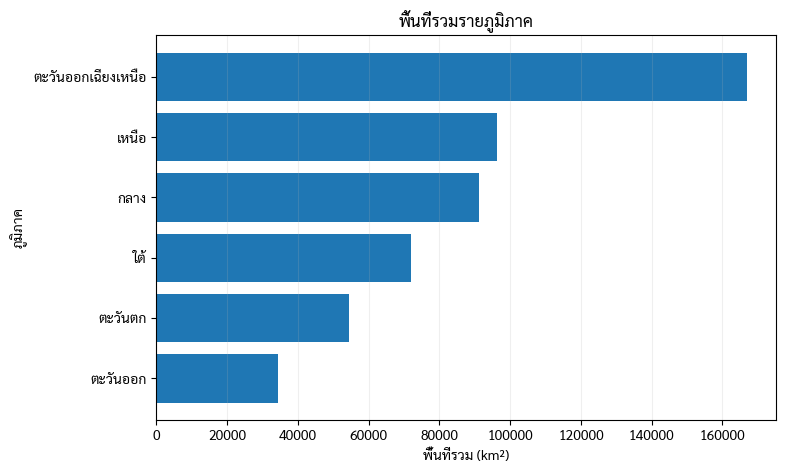

In [35]:
plot_region = region_stats.sort_values(
    "total_area_km2",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_region["REGION_TH"],
    plot_region["total_area_km2"]
)

ax.set_title("พื้นที่รวมรายภูมิภาค")
ax.set_xlabel("พื้นที่รวม (km²)")
ax.set_ylabel("ภูมิภาค")
ax.grid(axis="x", alpha=0.2)

plt.show()

## 38. กราฟจำนวนจังหวัดต่อภูมิภาค

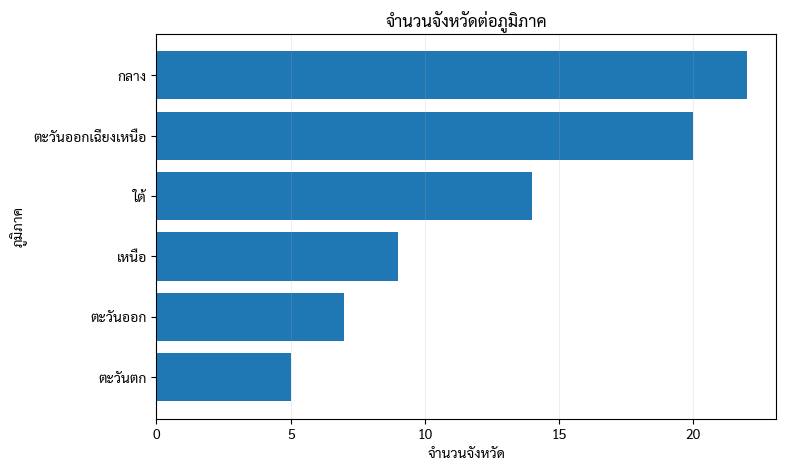

In [36]:
plot_count = region_stats.sort_values(
    "province_count",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_count["REGION_TH"],
    plot_count["province_count"]
)

ax.set_title("จำนวนจังหวัดต่อภูมิภาค")
ax.set_xlabel("จำนวนจังหวัด")
ax.set_ylabel("ภูมิภาค")
ax.grid(axis="x", alpha=0.2)

plt.show()

### Interpretation

เปรียบเทียบกราฟสองอัน:

```text
Number of provinces
≠
Total area
```

ภูมิภาคที่มีจังหวัดมากที่สุดไม่จำเป็นต้องมีพื้นที่รวมมากที่สุด

นี่เป็นตัวอย่างของการที่ **หน่วยการนับ** และ **ตัวแปรเชิงพื้นที่** ตอบคำถามคนละแบบ

# Part J — Interactive Folium Map

## 39. Analysis CRS → Display CRS

การวิเคราะห์พื้นที่ทำใน EPSG:6933  
แต่ Folium ใช้ Longitude / Latitude สำหรับ vector overlay

```text
EPSG:6933
analysis
↓
to_crs(EPSG:4326)
↓
Folium
display
```

In [37]:
province_web = province_region.to_crs(
    "EPSG:4326"
)

top10_codes = set(
    top10["ADM1_PCODE"]
)

province_web["is_top10"] = (
    province_web["ADM1_PCODE"]
    .isin(top10_codes)
)

print("Web CRS:", province_web.crs)

Web CRS: EPSG:4326


In [38]:
m = folium.Map(
    location=[13.5, 101.0],
    zoom_start=5,
    tiles=None,
    control_scale=True
)

basemap = xyz.OpenTopoMap

folium.TileLayer(
    tiles=basemap.build_url(),
    attr=basemap.html_attribution,
    name="OpenTopoMap",
    overlay=False,
    control=True,
    show=True
).add_to(m)

## 40. Folium Choropleth — Province Area

In [39]:
folium.Choropleth(
    geo_data=province_web,
    data=province_web,
    columns=[
        "ADM1_PCODE",
        "area_km2"
    ],
    key_on="feature.properties.ADM1_PCODE",
    fill_color="YlGnBu",
    fill_opacity=0.65,
    line_opacity=0.6,
    legend_name="Province area (km²)",
    name="Province area"
).add_to(m)

folium.GeoJson(
    province_web,
    name="Province information",
    style_function=lambda feature: {
        "fillOpacity": 0.0,
        "color": "#444444",
        "weight": 0.6
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "ADM1_TH",
            "ADM1_EN",
            "area_km2",
            "REGION_TH"
        ],
        aliases=[
            "จังหวัด:",
            "Province:",
            "Area (km²):",
            "ภูมิภาค:"
        ],
        localize=True
    )
).add_to(m)

## 41. Top 10 layer

In [40]:
top10_web = province_web[
    province_web["is_top10"]
].copy()

folium.GeoJson(
    top10_web,
    name="Top 10 largest",
    style_function=lambda feature: {
        "fillColor": "#ff9800",
        "fillOpacity": 0.55,
        "color": "#111111",
        "weight": 2
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "ADM1_TH",
            "area_km2"
        ],
        aliases=[
            "จังหวัด:",
            "Area (km²):"
        ],
        localize=True
    )
).add_to(m)

folium.LayerControl(
    collapsed=False
).add_to(m)

m

# Part K — Publication-quality Maps

## 42. Helper functions

เราจะใช้ publication maps เป็น output หลักสำหรับรายงานและบทความ

In [41]:
def add_north_arrow(
    ax,
    x=0.92,
    y=0.10,
    size=0.09
):
    ax.annotate(
        "N",
        xy=(x, y + size),
        xytext=(x, y),
        xycoords=ax.transAxes,
        textcoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=1.4,
            color="black"
        )
    )


def choose_scale_m(width_m):
    candidates = np.array([
        10_000, 20_000, 50_000, 100_000,
        200_000, 500_000, 1_000_000
    ])

    target = width_m / 4

    return int(
        candidates[
            np.argmin(
                np.abs(candidates - target)
            )
        ]
    )


def add_projected_scalebar(ax):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    width_m = xmax - xmin
    height_m = ymax - ymin

    scale_m = choose_scale_m(width_m)

    x0 = xmin + 0.08 * width_m
    y0 = ymin + 0.06 * height_m
    x1 = x0 + scale_m

    ax.plot(
        [x0, x1],
        [y0, y0],
        color="black",
        linewidth=3
    )

    tick = 0.01 * height_m

    ax.plot(
        [x0, x0],
        [y0 - tick, y0 + tick],
        color="black",
        linewidth=1.2
    )

    ax.plot(
        [x1, x1],
        [y0 - tick, y0 + tick],
        color="black",
        linewidth=1.2
    )

    ax.text(
        (x0 + x1) / 2,
        y0 + 0.02 * height_m,
        f"{scale_m/1000:g} km",
        ha="center",
        va="bottom",
        fontsize=8.5
    )

## 43. Publication Map 1 — Province Area Choropleth

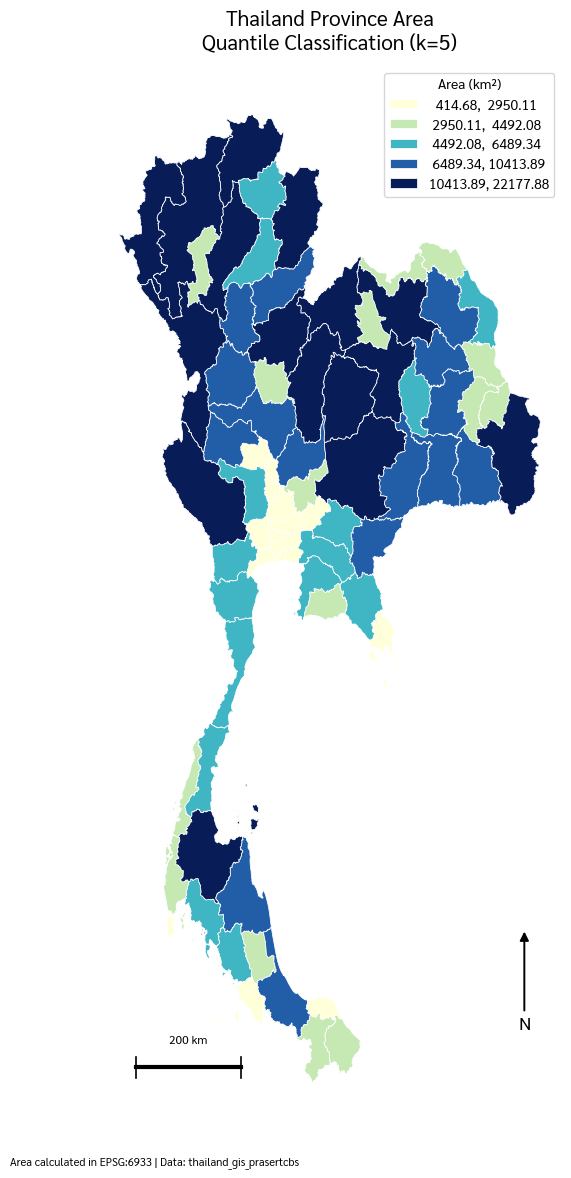

In [42]:
fig_area, ax = plt.subplots(figsize=(8, 12))

province_region.plot(
    ax=ax,
    column="area_km2",
    scheme="Quantiles",
    k=5,
    cmap="YlGnBu",
    legend=True,
    edgecolor="white",
    linewidth=0.55,
    legend_kwds={
        "title": "Area (km²)"
    }
)

ax.set_title(
    "Thailand Province Area\n"
    "Quantile Classification (k=5)",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

add_north_arrow(ax)
add_projected_scalebar(ax)

fig_area.text(
    0.10,
    0.025,
    "Area calculated in EPSG:6933 | Data: thailand_gis_prasertcbs",
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

## 44. Publication Map 2 — Province by Region

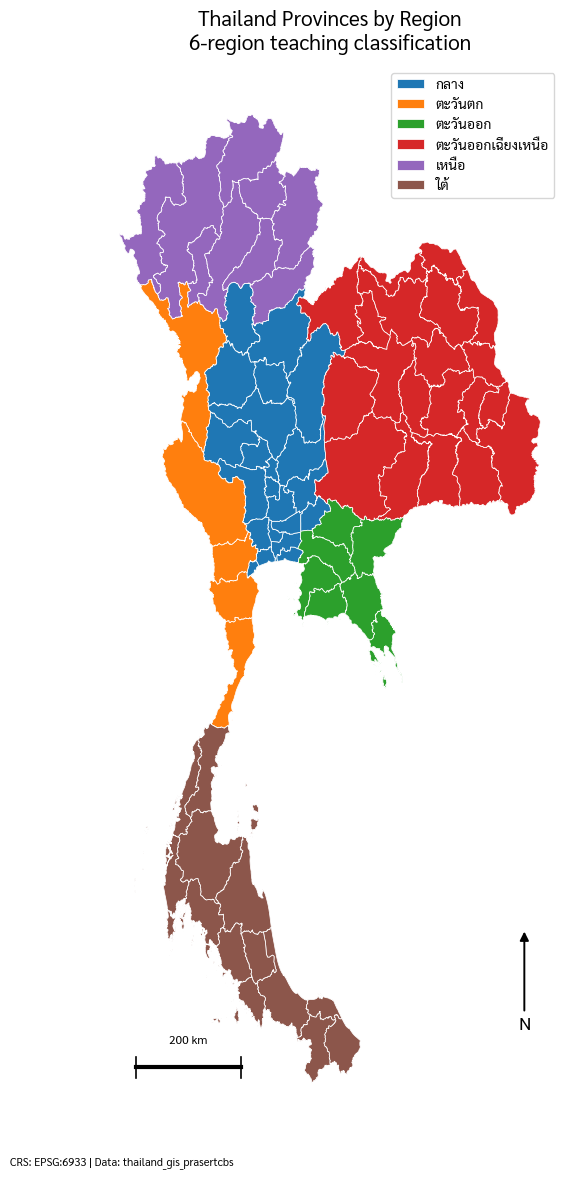

In [43]:
fig_region, ax = plt.subplots(figsize=(8, 12))

province_region.plot(
    ax=ax,
    column="REGION_TH",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.55
)

ax.set_title(
    "Thailand Provinces by Region\n"
    "6-region teaching classification",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

add_north_arrow(ax)
add_projected_scalebar(ax)

fig_region.text(
    0.10,
    0.025,
    "CRS: EPSG:6933 | Data: thailand_gis_prasertcbs",
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

## 45. Publication Map 3 — Top 10 Largest Provinces

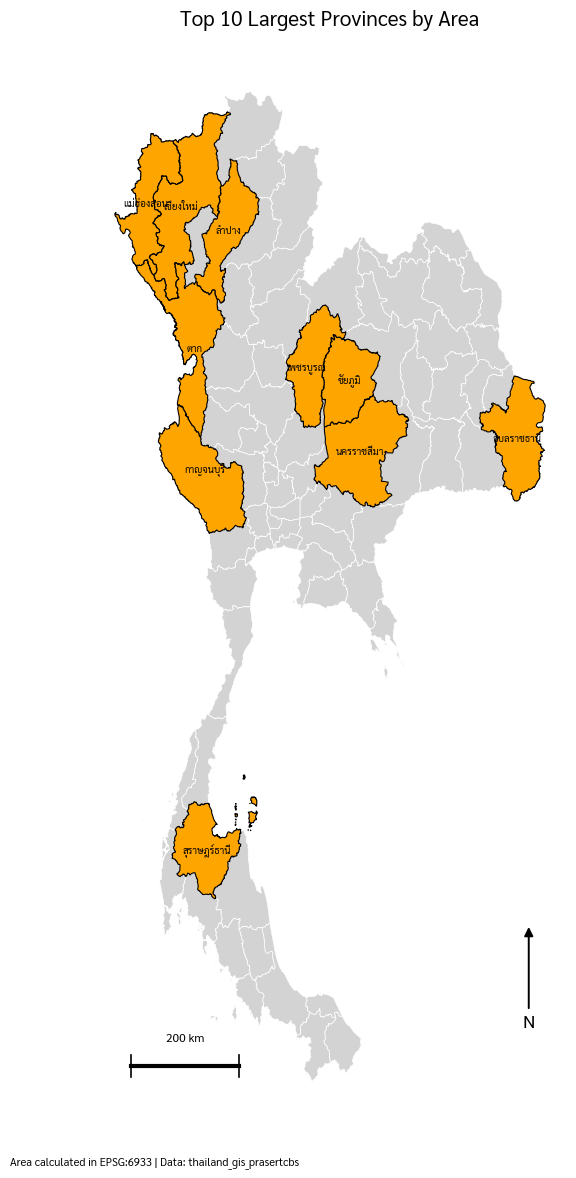

In [44]:
fig_top10, ax = plt.subplots(figsize=(8, 12))

province_region.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="white",
    linewidth=0.5
)

top10_pub = province_region[
    province_region["ADM1_PCODE"]
    .isin(top10_codes)
].copy()

top10_pub.plot(
    ax=ax,
    facecolor="orange",
    edgecolor="black",
    linewidth=0.8
)

top10_label = (
    top10_pub.geometry
    .representative_point()
)

for idx, pt in top10_label.items():
    ax.text(
        pt.x,
        pt.y,
        str(
            top10_pub.loc[
                idx,
                "ADM1_TH"
            ]
        ),
        fontsize=7,
        ha="center",
        va="center"
    )

ax.set_title(
    "Top 10 Largest Provinces by Area",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

add_north_arrow(ax)
add_projected_scalebar(ax)

fig_top10.text(
    0.10,
    0.025,
    "Area calculated in EPSG:6933 | Data: thailand_gis_prasertcbs",
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

# Part L — Export

## 46. สร้าง output folders

In [45]:
MAP_DIR = OUTPUT_DIR / "maps"
VECTOR_DIR = OUTPUT_DIR / "vectors"
TABLE_DIR = OUTPUT_DIR / "tables"
HTML_DIR = OUTPUT_DIR / "html"

for folder in [
    MAP_DIR,
    VECTOR_DIR,
    TABLE_DIR,
    HTML_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

## 47. Export PNG 300 dpi

In [46]:
area_png = MAP_DIR / "province_area_choropleth_300dpi.png"
region_png = MAP_DIR / "province_region_map_300dpi.png"
top10_png = MAP_DIR / "top10_largest_provinces_300dpi.png"

fig_area.savefig(
    area_png,
    dpi=300,
    bbox_inches="tight"
)

fig_region.savefig(
    region_png,
    dpi=300,
    bbox_inches="tight"
)

fig_top10.savefig(
    top10_png,
    dpi=300,
    bbox_inches="tight"
)

print(area_png)
print(region_png)
print(top10_png)

/content/gis03_outputs/maps/province_area_choropleth_300dpi.png
/content/gis03_outputs/maps/province_region_map_300dpi.png
/content/gis03_outputs/maps/top10_largest_provinces_300dpi.png


## 48. Export GeoPackage

GeoPackage จะเก็บ analytical layer ใน EPSG:6933

In [47]:
gpkg_path = VECTOR_DIR / "thailand_province_analysis.gpkg"

if gpkg_path.exists():
    gpkg_path.unlink()

province_region.to_file(
    gpkg_path,
    layer="province_area_region",
    driver="GPKG"
)

print("Saved:", gpkg_path)

Saved: /content/gis03_outputs/vectors/thailand_province_analysis.gpkg


## 49. Export Shapefile ZIP

In [48]:
shp_folder = VECTOR_DIR / "thailand_province_analysis"

if shp_folder.exists():
    shutil.rmtree(shp_folder)

shp_folder.mkdir(
    parents=True,
    exist_ok=True
)

shp_path = shp_folder / "thailand_province_analysis.shp"

# Shapefile จำกัดชื่อ field; ใช้ subset ที่สั้นและชัดเจน
province_shp = province_region[
    [
        "ADM1_PCODE",
        "ADM1_EN",
        "ADM1_TH",
        "REGION_EN",
        "REGION_TH",
        "area_km2",
        "geometry"
    ]
].copy()

province_shp.to_file(
    shp_path,
    driver="ESRI Shapefile",
    encoding="UTF-8"
)

shp_zip = shutil.make_archive(
    str(VECTOR_DIR / "thailand_province_analysis"),
    "zip",
    root_dir=shp_folder
)

print("Saved:", shp_zip)

Saved: /content/gis03_outputs/vectors/thailand_province_analysis.zip


## 50. Export CSV tables

In [49]:
province_rank = (
    province_region[
        [
            "ADM1_PCODE",
            "ADM1_EN",
            "ADM1_TH",
            "REGION_TH",
            "area_km2"
        ]
    ]
    .sort_values(
        "area_km2",
        ascending=False
    )
    .reset_index(drop=True)
)

province_rank["rank"] = (
    province_rank.index + 1
)

province_rank = province_rank[
    [
        "rank",
        "ADM1_PCODE",
        "ADM1_EN",
        "ADM1_TH",
        "REGION_TH",
        "area_km2"
    ]
]

province_csv = TABLE_DIR / "province_area_rank.csv"
region_csv = TABLE_DIR / "region_statistics.csv"
desc_csv = TABLE_DIR / "province_area_descriptive_statistics.csv"

province_rank.to_csv(
    province_csv,
    index=False,
    encoding="utf-8-sig"
)

region_stats.to_csv(
    region_csv,
    index=False,
    encoding="utf-8-sig"
)

area_desc.to_csv(
    desc_csv,
    encoding="utf-8-sig"
)

print(province_csv)
print(region_csv)
print(desc_csv)

/content/gis03_outputs/tables/province_area_rank.csv
/content/gis03_outputs/tables/region_statistics.csv
/content/gis03_outputs/tables/province_area_descriptive_statistics.csv


## 51. Export Folium HTML

In [50]:
html_path = HTML_DIR / "thailand_province_interactive.html"

m.save(html_path)

print("Saved:", html_path)

Saved: /content/gis03_outputs/html/thailand_province_interactive.html


## 52. ตรวจ outputs

In [51]:
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(
            p.relative_to(OUTPUT_DIR),
            f"({p.stat().st_size/1024:,.1f} KB)"
        )

html/thailand_province_interactive.html (4,050.6 KB)
maps/province_area_choropleth_300dpi.png (520.1 KB)
maps/province_region_map_300dpi.png (516.9 KB)
maps/top10_largest_provinces_300dpi.png (468.6 KB)
tables/province_area_descriptive_statistics.csv (0.2 KB)
tables/province_area_rank.csv (6.5 KB)
tables/region_statistics.csv (0.6 KB)
vectors/thailand_province_analysis/thailand_province_analysis.cpg (0.0 KB)
vectors/thailand_province_analysis/thailand_province_analysis.dbf (32.2 KB)
vectors/thailand_province_analysis/thailand_province_analysis.prj (0.4 KB)
vectors/thailand_province_analysis/thailand_province_analysis.shp (684.8 KB)
vectors/thailand_province_analysis/thailand_province_analysis.shx (0.7 KB)
vectors/thailand_province_analysis.gpkg (852.0 KB)
vectors/thailand_province_analysis.zip (457.1 KB)


# Concept Check

ลองตอบโดยไม่ย้อนดู code

1. ทำไมเราไม่ใช้ `Shape_Area` ทันที?
2. เหตุใดจึงใช้ EPSG:6933 กับการเปรียบเทียบพื้นที่จังหวัดทั้งประเทศ?
3. `ADM1_PCODE` มีประโยชน์อย่างไร?
4. Reference map ต่างจาก choropleth อย่างไร?
5. Categorical map ต่างจาก choropleth อย่างไร?
6. Equal Interval ต่างจาก Quantiles อย่างไร?
7. ทำไมแผนที่จาก dataset เดียวกันจึงเปลี่ยนเมื่อ classification scheme เปลี่ยน?
8. `groupby()` ใช้ตอบคำถาม GIS แบบใด?
9. ทำไม province count ไม่เหมือน province area?
10. ทำไม Folium layer ต้องแปลงกลับเป็น EPSG:4326?

# Exercise 1 — 10 จังหวัดพื้นที่น้อยที่สุด

ใช้

```python
.nsmallest(10, "area_km2")
```

แล้วสร้าง

1. ตาราง
2. horizontal bar chart
3. highlight map

เปรียบเทียบ spatial pattern กับ Top 10 largest provinces

# Exercise 2 — Query จังหวัดจากพื้นที่

สร้าง query อย่างน้อย 2 แบบ:

### A
พื้นที่มากกว่า 12,000 km²

### B
พื้นที่ระหว่าง 3,000–6,000 km²

สำหรับแต่ละ query:

```text
query
↓
count
↓
table
↓
map
↓
interpret
```

# Exercise 3 — Equal Interval vs Quantiles

สร้าง choropleth 2 แผนที่จาก `area_km2`

- Equal Interval, k=5
- Quantiles, k=5

ตอบ:

1. สีของจังหวัดใดเปลี่ยน?
2. วิธีใดทำให้จำนวนจังหวัดต่อ class สมดุลกว่า?
3. วิธีใดรักษาช่วงค่าของตัวเลขได้ตรงไปตรงมากว่า?
4. ถ้าจะใช้ในงานวิจัย คุณจะเลือกวิธีใด และเพราะอะไร?

# Exercise 4 — เลือกหนึ่งภูมิภาค

เลือกหนึ่งภูมิภาค เช่น

```text
เหนือ
ตะวันออกเฉียงเหนือ
ใต้
```

แล้ว

1. Query จังหวัดในภูมิภาค
2. สรุปจำนวนจังหวัด
3. คำนวณพื้นที่รวม
4. หา 3 จังหวัดใหญ่ที่สุด
5. ทำแผนที่เฉพาะภูมิภาค
6. Export GeoPackage

# Exercise 5 — QGIS workflow

เปิดไฟล์ต่อไปนี้ใน QGIS

```text
thailand_province_analysis.gpkg
```

ตรวจ:

- CRS
- attributes
- ภาษาไทย
- `area_km2`
- `REGION_TH`

แล้วทดลอง symbol แบบ Graduated โดยใช้ `area_km2`

เปรียบเทียบผลกับ choropleth ที่สร้างจาก Python

# MSc Challenge — Classification Sensitivity

สร้างแผนที่จาก dataset เดียวกันด้วย

```text
Equal Interval
Quantiles
Natural Breaks / Fisher-Jenks
```

แล้วอภิปราย:

1. เหตุใด spatial pattern ที่เห็นจึงต่างกัน?
2. classification scheme ใดเหมาะกับ distribution ของพื้นที่จังหวัดมากที่สุด?
3. การเลือก class break สามารถมีอิทธิพลต่อข้อสรุปของผู้อ่านหรือไม่?
4. งานวิจัยควรรายงาน classification method ใน Methods หรือ Figure caption หรือไม่?

> จุดประสงค์ไม่ใช่หา “วิธีที่ดีที่สุดเพียงวิธีเดียว” แต่เพื่อเข้าใจว่า **cartographic choices influence interpretation**

# Summary

Notebook 03 เปลี่ยนจากการวัดเชิงพื้นที่ ไปสู่การวิเคราะห์และสื่อสารข้อมูลจังหวัด

แนวคิดหลัก:

$$
\boxed{
\text{Polygon}
+
\text{Attribute}
+
\text{Measurement}
+
\text{Statistics}
+
\text{Thematic Mapping}
}
$$

สิ่งที่ต้องจำ:

> **Attribute field ≠ automatically correct measurement**

> **Categorical map ≠ Choropleth**

> **Count ≠ Density**

> **More colors ≠ Better map**

> **A map is an analytical argument, not merely decoration.**

## ต่อไป: Notebook 04

**Thailand District GIS — Administrative Hierarchy, GroupBy & Spatial Query**

คำถามเปิดบท:

> เมื่อจังหวัดประกอบด้วยหลายอำเภอ เราจะใช้ทั้ง attribute hierarchy และ spatial relationships เพื่อตรวจว่า “อำเภอใดอยู่ในจังหวัดใด” ได้อย่างไร?